# Final Patient-Level Split Creation

This notebook creates the **patient/case-level holdout test split** and the **custom 5-fold development splits** for the thesis segmentation pipeline.

## Methodological decisions

1. **Split at the case level, never at the scan level.** Repeated measures from the same individual must not be split across training and test, because that causes information leakage and can inflate performance. citeturn179070search7turn179070search11

2. **Use the anatomical-variation strata for balancing.** We use the case-level provisional variation strata from the previous notebook to keep the holdout test set and development folds reasonably balanced. Scikit-learn's stratified splitters are intended exactly for preserving class proportions during splitting. citeturn179070search0turn179070search12

3. **Use a holdout test set plus 5-fold development splits.** nnU-Net uses 5-fold cross-validation by default over training cases, and it supports **custom manual splits** through a `splits_final.json` file. citeturn993367search0turn993367search2

4. **Keep the test set locked.** Split first, then freeze the test set. Do not use the test set for tuning or re-fitting score normalization. This follows standard anti-leakage practice in machine learning. citeturn179070search6turn179070search11


In [1]:
from pathlib import Path
import sys
import json

def find_project_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()
    for path in [start_path] + list(start_path.parents):
        if (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing src/")

project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Current working directory:", Path.cwd())
print("Project root:", project_root)


Current working directory: c:\Users\P102832\Downloads\thesis_segmentation\notebooks\01_eda
Project root: C:\Users\P102832\Downloads\thesis_segmentation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold


## Load the case-level variation scores

This notebook expects the previous variation-score notebook to have saved:

```text
metadata/eda/final_variation_score/variation_scores_per_case.csv
```

The file should contain at least:

- `case_id`
- `primary_variation_score`
- `primary_variation_stratum`
- `n_scans`


In [3]:
variation_path = project_root / "metadata" / "eda" / "final_variation_score" / "variation_scores_per_case.csv"

if not variation_path.exists():
    raise FileNotFoundError(
        f"Missing variation score file: {variation_path}\n"
        "Run 12_final_anatomical_variation_score.ipynb first."
    )

case_scores_df = pd.read_csv(variation_path)

required_cols = {
    "case_id",
    "primary_variation_score",
    "primary_variation_stratum",
    "n_scans",
}
missing_cols = required_cols - set(case_scores_df.columns)
if missing_cols:
    raise ValueError(f"variation_scores_per_case.csv is missing required columns: {missing_cols}")

case_scores_df = case_scores_df.sort_values("case_id").reset_index(drop=True)
print("Number of cases:", len(case_scores_df))
case_scores_df.head()


Number of cases: 85


,case_id,n_scans,primary_variation_score,sensitivity_variation_score,n_primary_features_used,n_sensitivity_features_used,primary_variation_stratum,sensitivity_variation_stratum
0,case101,4,0.830722,0.904521,30.0,35.0,medium,medium
1,case102,1,1.214836,1.132832,30.0,35.0,high,high
2,case107,3,0.755705,0.733067,30.0,35.0,medium,medium
3,case108,3,0.888311,0.878371,30.0,35.0,medium,medium
4,case11,3,0.943960,0.943751,30.0,35.0,high,high


## Split design

We use:
- **20% holdout test set** at the case level
- **80% development pool** at the case level
- **5-fold stratified CV** inside the development pool

Why 20%? With 85 cases, this gives about 17 holdout test cases, which is large enough to be meaningful while leaving about 68 cases for development. Five folds on the development pool then gives roughly 13 to 14 validation cases per fold, which is practical and aligns with the usual nnU-Net 5-fold workflow. nnU-Net supports custom manual split files, so this design is compatible with the downstream training pipeline. citeturn993367search0turn993367search2


In [4]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

print("RANDOM_STATE:", RANDOM_STATE)
print("TEST_SIZE:", TEST_SIZE)
print("N_SPLITS:", N_SPLITS)


RANDOM_STATE: 42
TEST_SIZE: 0.2
N_SPLITS: 5


In [5]:
# Holdout test split at the CASE level
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X = case_scores_df[["case_id"]].copy()
y = case_scores_df["primary_variation_stratum"].copy()

train_dev_idx, test_idx = next(splitter.split(X, y))

dev_cases_df = case_scores_df.iloc[train_dev_idx].copy().reset_index(drop=True)
test_cases_df = case_scores_df.iloc[test_idx].copy().reset_index(drop=True)

dev_cases_df["split"] = "dev"
test_cases_df["split"] = "test"

split_cases_df = pd.concat([dev_cases_df, test_cases_df], ignore_index=True).sort_values("case_id").reset_index(drop=True)

print("Development cases:", len(dev_cases_df))
print("Test cases:", len(test_cases_df))
split_cases_df.head()


Development cases: 68
Test cases: 17


,case_id,n_scans,primary_variation_score,sensitivity_variation_score,n_primary_features_used,n_sensitivity_features_used,primary_variation_stratum,sensitivity_variation_stratum,split
0,case101,4,0.830722,0.904521,30.0,35.0,medium,medium,dev
1,case102,1,1.214836,1.132832,30.0,35.0,high,high,dev
2,case107,3,0.755705,0.733067,30.0,35.0,medium,medium,dev
3,case108,3,0.888311,0.878371,30.0,35.0,medium,medium,test
4,case11,3,0.943960,0.943751,30.0,35.0,high,high,dev


## Balance check: holdout test split

In [6]:
holdout_balance_df = (
    split_cases_df
    .groupby(["split", "primary_variation_stratum"])
    .size()
    .reset_index(name="n_cases")
    .sort_values(["split", "primary_variation_stratum"])
)

holdout_score_summary_df = (
    split_cases_df
    .groupby("split")["primary_variation_score"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .reset_index()
)

holdout_balance_df, holdout_score_summary_df


(  split primary_variation_stratum  n_cases
 0   dev                      high       22
 1   dev                       low       23
 2   dev                    medium       23
 3  test                      high        6
 4  test                       low        6
 5  test                    medium        5,
   split  count      mean    median       min       max       std
 0   dev     68  0.847039  0.786597  0.464115  1.712569  0.253850
 1  test     17  0.848576  0.776780  0.555468  1.562197  0.267017)

<Figure size 700x400 with 0 Axes>

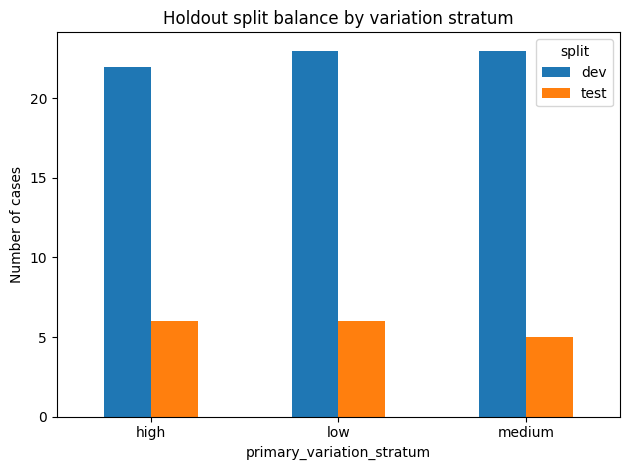

In [7]:
plt.figure(figsize=(7, 4))
plot_df = holdout_balance_df.pivot(index="primary_variation_stratum", columns="split", values="n_cases").fillna(0)
plot_df.plot(kind="bar", rot=0)
plt.ylabel("Number of cases")
plt.title("Holdout split balance by variation stratum")
plt.tight_layout()
plt.show()


## Create 5-fold stratified development splits

Because we have already collapsed the data to **one row per case**, the patient/group leakage problem has already been solved at this stage. We now stratify across the development cases only. Scikit-learn's `StratifiedKFold` preserves class proportions across folds, and nnU-Net will accept custom split files derived from these case-level train/validation assignments. citeturn179070search4turn993367search0


In [8]:
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

dev_X = dev_cases_df[["case_id"]].copy()
dev_y = dev_cases_df["primary_variation_stratum"].copy()

fold_rows = []
nnunet_splits = []

for fold_id, (train_idx, val_idx) in enumerate(skf.split(dev_X, dev_y)):
    fold_train_cases = dev_cases_df.iloc[train_idx]["case_id"].tolist()
    fold_val_cases = dev_cases_df.iloc[val_idx]["case_id"].tolist()

    nnunet_splits.append({
        "train": fold_train_cases,
        "val": fold_val_cases,
    })

    for case_id in fold_train_cases:
        fold_rows.append({"fold": fold_id, "case_id": case_id, "fold_role": "train"})
    for case_id in fold_val_cases:
        fold_rows.append({"fold": fold_id, "case_id": case_id, "fold_role": "val"})

fold_assignments_df = pd.DataFrame(fold_rows)
fold_assignments_df.head()


,fold,case_id,fold_role
0,0,case130,train
1,0,case53,train
2,0,case29,train
3,0,case139,train
4,0,case74,train


## Balance checks for the 5 development folds

In [9]:
dev_case_strata_df = dev_cases_df[["case_id", "primary_variation_stratum", "primary_variation_score"]].copy()

fold_balance_df = (
    fold_assignments_df
    .merge(dev_case_strata_df, on="case_id", how="left")
    .groupby(["fold", "fold_role", "primary_variation_stratum"])
    .size()
    .reset_index(name="n_cases")
    .sort_values(["fold", "fold_role", "primary_variation_stratum"])
)

fold_score_summary_df = (
    fold_assignments_df
    .merge(dev_case_strata_df, on="case_id", how="left")
    .groupby(["fold", "fold_role"])["primary_variation_score"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .reset_index()
)

fold_balance_df.head(20), fold_score_summary_df.head(10)


(    fold fold_role primary_variation_stratum  n_cases
 0      0     train                      high       18
 1      0     train                       low       18
 2      0     train                    medium       18
 3      0       val                      high        4
 4      0       val                       low        5
 5      0       val                    medium        5
 6      1     train                      high       17
 7      1     train                       low       18
 8      1     train                    medium       19
 9      1       val                      high        5
 10     1       val                       low        5
 11     1       val                    medium        4
 12     2     train                      high       17
 13     2     train                       low       18
 14     2     train                    medium       19
 15     2       val                      high        5
 16     2       val                       low        5
 17     2 

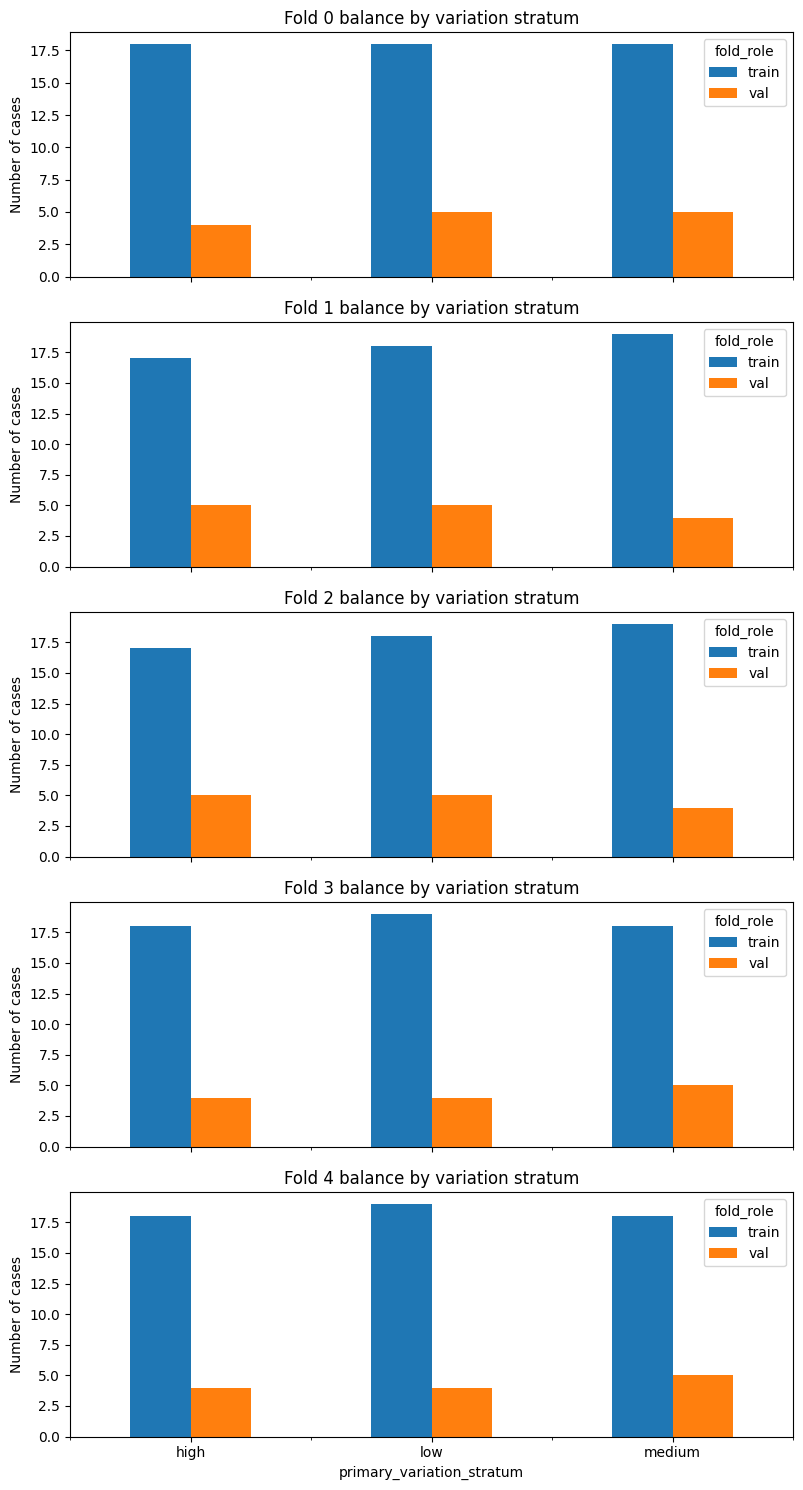

In [10]:
fig, axes = plt.subplots(nrows=N_SPLITS, ncols=1, figsize=(8, 3*N_SPLITS), sharex=True)

for fold_id in range(N_SPLITS):
    ax = axes[fold_id]
    plot_df = fold_balance_df[fold_balance_df["fold"] == fold_id].pivot(
        index="primary_variation_stratum",
        columns="fold_role",
        values="n_cases",
    ).fillna(0)
    plot_df.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"Fold {fold_id} balance by variation stratum")
    ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()


## Build the scan-level modeling manifest

This manifest maps each scan file to:
- `case_id`
- case-level split (`dev` or `test`)
- development fold role (`train` / `val`) for each fold

This is the table that the downstream nnU-Net dataset-preparation step should use.


In [11]:
organ_long_path = project_root / "metadata" / "eda" / "final_mask_level_totalseg" / "organ_level_long_qc.csv"

if not organ_long_path.exists():
    raise FileNotFoundError(
        f"Missing organ-level table: {organ_long_path}\n"
        "Run the final mask-level EDA notebook first."
    )

organ_long_df = pd.read_csv(organ_long_path)

scan_manifest_df = (
    organ_long_df[["file_name"]]
    .drop_duplicates()
    .copy()
)

scan_manifest_df["case_id"] = scan_manifest_df["file_name"].str.extract(r"^(case\d+)_day")
scan_manifest_df = scan_manifest_df.merge(
    split_cases_df[["case_id", "split", "primary_variation_score", "primary_variation_stratum", "n_scans"]],
    on="case_id",
    how="left",
)

scan_manifest_df["scan_path"] = scan_manifest_df["file_name"].apply(
    lambda x: f"{{public_root}}/{x}"
)
scan_manifest_df["mask_path"] = scan_manifest_df["file_name"].apply(
    lambda x: f"{{totalseg_root}}/{x}"
)

scan_manifest_df = scan_manifest_df.sort_values(["case_id", "file_name"]).reset_index(drop=True)

print("Number of scans in modeling manifest:", len(scan_manifest_df))
scan_manifest_df.head()


Number of scans in modeling manifest: 274


,file_name,case_id,split,primary_variation_score,primary_variation_stratum,n_scans,scan_path,mask_path
0,case101_day20.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day20.nii.gz,{totalseg_root}/case101_day20.nii.gz
1,case101_day22.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day22.nii.gz,{totalseg_root}/case101_day22.nii.gz
2,case101_day26.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day26.nii.gz,{totalseg_root}/case101_day26.nii.gz
3,case101_day32.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day32.nii.gz,{totalseg_root}/case101_day32.nii.gz
4,case102_day0.nii.gz,case102,dev,1.214836,high,1,{public_root}/case102_day0.nii.gz,{totalseg_root}/case102_day0.nii.gz


## Expand development folds to scan-level tables

nnU-Net itself only needs case identifiers in the custom split JSON, but for auditability it is useful to also save scan-level CSV views.


In [12]:
scan_fold_rows = []

for fold_id, split_def in enumerate(nnunet_splits):
    train_cases = set(split_def["train"])
    val_cases = set(split_def["val"])

    fold_scans = scan_manifest_df[scan_manifest_df["split"] == "dev"].copy()
    fold_scans["fold"] = fold_id
    fold_scans["fold_role"] = np.where(
        fold_scans["case_id"].isin(train_cases),
        "train",
        np.where(fold_scans["case_id"].isin(val_cases), "val", "unknown")
    )

    if (fold_scans["fold_role"] == "unknown").any():
        raise ValueError(f"Unknown fold assignment found in fold {fold_id}")

    scan_fold_rows.append(fold_scans)

scan_fold_manifest_df = pd.concat(scan_fold_rows, ignore_index=True)
scan_fold_manifest_df.head()


,file_name,case_id,split,primary_variation_score,primary_variation_stratum,n_scans,scan_path,mask_path,fold,fold_role
0,case101_day20.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day20.nii.gz,{totalseg_root}/case101_day20.nii.gz,0,val
1,case101_day22.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day22.nii.gz,{totalseg_root}/case101_day22.nii.gz,0,val
2,case101_day26.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day26.nii.gz,{totalseg_root}/case101_day26.nii.gz,0,val
3,case101_day32.nii.gz,case101,dev,0.830722,medium,4,{public_root}/case101_day32.nii.gz,{totalseg_root}/case101_day32.nii.gz,0,val
4,case102_day0.nii.gz,case102,dev,1.214836,high,1,{public_root}/case102_day0.nii.gz,{totalseg_root}/case102_day0.nii.gz,0,val


## Save outputs

We save:
- `patient_level_holdout_test.csv`
- `dev_case_table.csv`
- `fold_assignments_case_level.csv`
- `modeling_manifest.csv`
- `scan_fold_manifest.csv`
- `nnunet_custom_splits.json`

The JSON file is written in the structure nnU-Net expects for manual custom splits, and can later be copied to the appropriate `nnUNet_preprocessed/DATASETXXX_NAME/splits_final.json` location. citeturn993367search0turn993367search2


In [13]:
output_split_dir = project_root / "splits"
output_split_dir.mkdir(parents=True, exist_ok=True)

output_model_dir = project_root / "metadata" / "modeling"
output_model_dir.mkdir(parents=True, exist_ok=True)

split_cases_df.to_csv(output_split_dir / "patient_level_holdout_test.csv", index=False)
dev_cases_df.to_csv(output_split_dir / "dev_case_table.csv", index=False)
fold_assignments_df.to_csv(output_split_dir / "fold_assignments_case_level.csv", index=False)
scan_manifest_df.to_csv(output_model_dir / "modeling_manifest.csv", index=False)
scan_fold_manifest_df.to_csv(output_model_dir / "scan_fold_manifest.csv", index=False)

with open(output_split_dir / "nnunet_custom_splits.json", "w", encoding="utf-8") as f:
    json.dump(nnunet_splits, f, indent=2)

print("Saved split outputs to:", output_split_dir)
print("Saved modeling outputs to:", output_model_dir)


Saved split outputs to: C:\Users\P102832\Downloads\thesis_segmentation\splits
Saved modeling outputs to: C:\Users\P102832\Downloads\thesis_segmentation\metadata\modeling


## Final interpretation

This split design is now ready for downstream preprocessing and nnU-Net dataset conversion.

### What is methodologically correct here
- repeated scans from the same case remain together
- the holdout test set is locked at the case level
- variation strata are balanced as much as possible
- custom 5-fold development splits are prepared for nnU-Net

### Important limitation
The variation strata are based on a **study-specific composite variation score** built from QC-filtered pseudo-mask features. This is appropriate for robust internal experimental design, but it is not a canonical clinical anatomical-variation index.
